# Set 4 Question 2 - Step 1 exploratory analysis

Goal: inspect `eco_data.xlsx`, visualize the two rotifer-alga co-culture experiments, and make a small first-pass summary for qualitative predator-prey dynamics.

The Excel file has no explicit time column, so this notebook uses the row order as `time`/observation index.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
EXCEL_PATH = PROJECT_ROOT / "data" / "eco_data.xlsx"
OUTPUT_DIR = PROJECT_ROOT / "output" / "set4_q2_step1"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Excel file: {EXCEL_PATH}")
print(f"Output folder: {OUTPUT_DIR}")

Excel file: F:\aging_code\homework\q-bio_homework\qbio_final_project\data\eco_data.xlsx
Output folder: F:\aging_code\homework\q-bio_homework\qbio_final_project\output\set4_q2_step1


## 1. Inspect the Excel file

First inspect sheet names, columns, and the first few rows. This keeps the parsing choices visible.

In [2]:
def inspect_excel_file(excel_path):
    xls = pd.ExcelFile(excel_path)
    print("Sheet names:", xls.sheet_names)

    for sheet_name in xls.sheet_names:
        df = pd.read_excel(excel_path, sheet_name=sheet_name)
        print("\n" + "=" * 80)
        print(f"Sheet: {sheet_name}")
        print(f"Shape: {df.shape}")
        print("Columns:", list(df.columns))
        display(df.head())


inspect_excel_file(EXCEL_PATH)

Sheet names: ['Experiment #1', 'Experiment #2']

Sheet: Experiment #1
Shape: (61, 2)
Columns: ['Predator, rotifer\n(arb units)', 'Prey, alga\n(arb units)']


,"Predator, rotifer\n(arb units)","Prey, alga\n(arb units)"
0,0.448065,5.064045
1,0.877633,3.216397
2,1.738027,1.430504
3,1.798108,0.198320
4,2.596955,0.073553



Sheet: Experiment #2
Shape: (34, 2)
Columns: ['Predator, rotifer\n(arb units)', 'Prey, alga\n(arb units)']


,"Predator, rotifer\n(arb units)","Prey, alga\n(arb units)"
0,0.061728,3.024604
1,0.122317,1.850800
2,0.244634,1.109007
3,0.367126,0.830089
4,0.612900,0.767396


## 2. Load and clean the two experiments

Each sheet is one experiment. The file contains predator and prey abundance columns but no explicit time column, so `time` is the row index in measurement order.

In [3]:
def load_experiment_tables(excel_path):
    sheet_to_experiment = {
        "Experiment #1": "experiment_1",
        "Experiment #2": "experiment_2",
    }

    experiments = {}
    for sheet_name, experiment_name in sheet_to_experiment.items():
        raw = pd.read_excel(excel_path, sheet_name=sheet_name)
        cleaned = pd.DataFrame({
            "time": np.arange(len(raw)),
            "rotifer": raw["Predator, rotifer\n(arb units)"],
            "alga": raw["Prey, alga\n(arb units)"],
        })
        cleaned = cleaned.sort_values("time").reset_index(drop=True)
        experiments[experiment_name] = cleaned

    return experiments


experiments = load_experiment_tables(EXCEL_PATH)
for name, df in experiments.items():
    print(f"{name}: {df.shape[0]} time points")
    display(df.head())

experiment_1: 61 time points


,time,rotifer,alga
0,0,0.448065,5.064045
1,1,0.877633,3.216397
2,2,1.738027,1.430504
3,3,1.798108,0.198320
4,4,2.596955,0.073553


experiment_2: 34 time points


,time,rotifer,alga
0,0,0.061728,3.024604
1,1,0.122317,1.850800
2,2,0.244634,1.109007
3,3,0.367126,0.830089
4,4,0.612900,0.767396


## 3. Helper functions for plotting and summary

In [4]:
def normalize_abundance(df):
    normalized = df.copy()
    normalized["alga_norm"] = normalized["alga"] / normalized["alga"].max()
    normalized["rotifer_norm"] = normalized["rotifer"] / normalized["rotifer"].max()
    return normalized


def plot_raw_timeseries(experiments, output_dir):
    for experiment_name, df in experiments.items():
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(df["time"], df["alga"], marker="o", linewidth=1.8, label="Prey: alga")
        ax.plot(df["time"], df["rotifer"], marker="o", linewidth=1.8, label="Predator: rotifer")
        ax.set_title(f"{experiment_name}: raw abundance time series")
        ax.set_xlabel("Time point (row order; no explicit time column in Excel)")
        ax.set_ylabel("Abundance (arb units)")
        ax.legend()
        fig.tight_layout()
        fig.savefig(output_dir / f"{experiment_name}_raw_timeseries.png", dpi=300)
        plt.show()


def plot_normalized_comparison(experiments, output_dir):
    fig, axes = plt.subplots(1, len(experiments), figsize=(12, 4), sharey=True)
    if len(experiments) == 1:
        axes = [axes]

    for ax, (experiment_name, df) in zip(axes, experiments.items()):
        normalized = normalize_abundance(df)
        ax.plot(normalized["time"], normalized["alga_norm"], marker="o", linewidth=1.8, label="Alga / max")
        ax.plot(normalized["time"], normalized["rotifer_norm"], marker="o", linewidth=1.8, label="Rotifer / max")
        ax.set_title(experiment_name)
        ax.set_xlabel("Time point")
        ax.set_ylim(0, 1.08)
        ax.legend()

    axes[0].set_ylabel("Normalized abundance")
    fig.suptitle("Normalized predator-prey dynamics", y=1.03)
    fig.tight_layout()
    fig.savefig(output_dir / "experiments_normalized_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()


def plot_phase_portraits(experiments, output_dir):
    fig, axes = plt.subplots(1, len(experiments), figsize=(12, 4))
    if len(experiments) == 1:
        axes = [axes]

    for ax, (experiment_name, df) in zip(axes, experiments.items()):
        ax.plot(df["alga"], df["rotifer"], marker="o", linewidth=1.8)
        ax.scatter(df["alga"].iloc[0], df["rotifer"].iloc[0], s=80, label="start")
        ax.scatter(df["alga"].iloc[-1], df["rotifer"].iloc[-1], s=80, label="end")
        ax.set_title(experiment_name)
        ax.set_xlabel("Alga abundance (prey)")
        ax.set_ylabel("Rotifer abundance (predator)")
        ax.legend()

    fig.suptitle("Phase portraits", y=1.03)
    fig.tight_layout()
    fig.savefig(output_dir / "phase_portraits.png", dpi=300, bbox_inches="tight")
    plt.show()

## 4. Plot raw and normalized dynamics

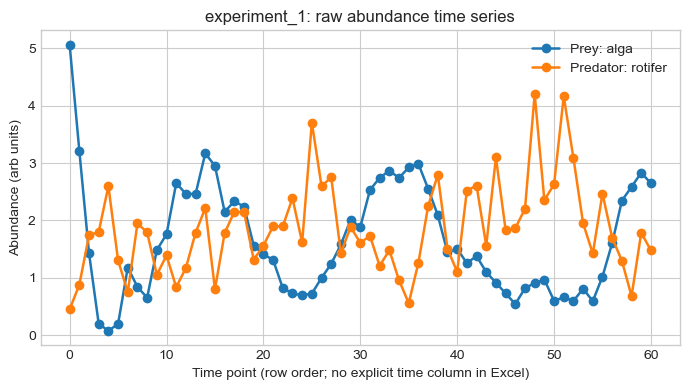

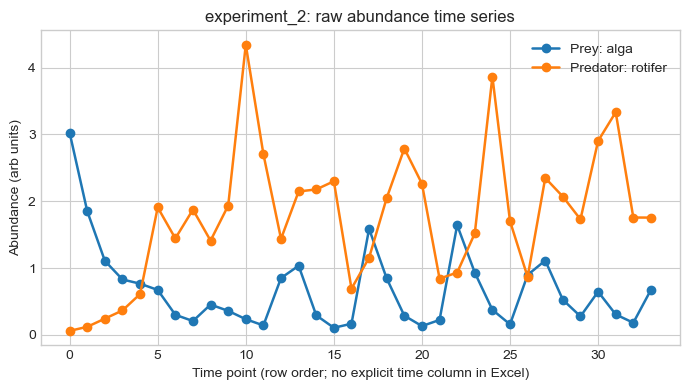

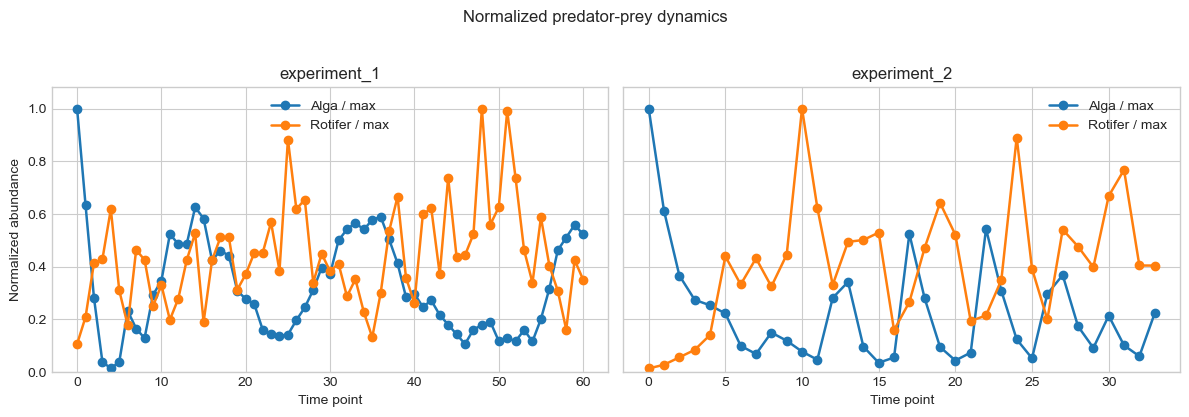

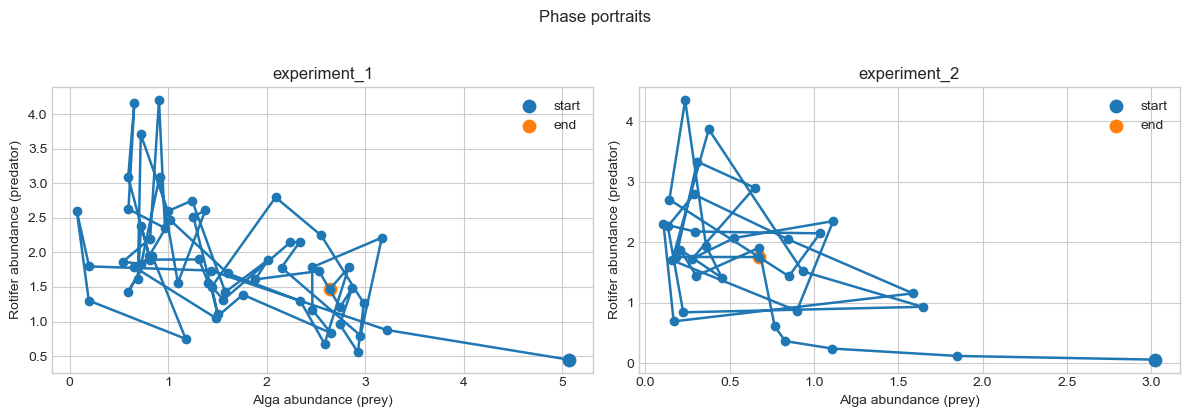

In [5]:
plot_raw_timeseries(experiments, OUTPUT_DIR)
plot_normalized_comparison(experiments, OUTPUT_DIR)
plot_phase_portraits(experiments, OUTPUT_DIR)

## 5. Summary table and first-pass interpretation

The peak lag below uses the global maximum of each species. It is a simple first-pass check, not a full oscillation or phase analysis.

In [6]:
def summarize_experiment(df, experiment_name):
    alga_peak_index = df["alga"].idxmax()
    rotifer_peak_index = df["rotifer"].idxmax()
    time_of_alga_max = df.loc[alga_peak_index, "time"]
    time_of_rotifer_max = df.loc[rotifer_peak_index, "time"]

    return {
        "experiment": experiment_name,
        "n_timepoints": len(df),
        "time_min": df["time"].min(),
        "time_max": df["time"].max(),
        "alga_min": df["alga"].min(),
        "alga_max": df["alga"].max(),
        "rotifer_min": df["rotifer"].min(),
        "rotifer_max": df["rotifer"].max(),
        "time_of_alga_max": time_of_alga_max,
        "time_of_rotifer_max": time_of_rotifer_max,
        "rotifer_peak_minus_alga_peak": time_of_rotifer_max - time_of_alga_max,
    }


def summarize_all_experiments(experiments, output_dir):
    summary = pd.DataFrame([
        summarize_experiment(df, experiment_name)
        for experiment_name, df in experiments.items()
    ])
    summary_path = output_dir / "experiment_summary.csv"
    summary.to_csv(summary_path, index=False)
    print(f"Saved summary table to: {summary_path}")
    return summary


def print_short_interpretation(summary):
    for _, row in summary.iterrows():
        lag = row["rotifer_peak_minus_alga_peak"]
        experiment = row["experiment"]
        if lag > 0:
            print(f"{experiment}: rotifer peak occurs {lag} time points after the alga peak.")
        elif lag == 0:
            print(f"{experiment}: rotifer and alga global peaks occur at the same time point.")
        else:
            print(f"{experiment}: rotifer peak occurs {-lag} time points before the alga peak.")

    print("\nInterpret this together with the figures: the global maximum is only a first-pass phase-lag summary.")


summary = summarize_all_experiments(experiments, OUTPUT_DIR)
display(summary)
print_short_interpretation(summary)

Saved summary table to: F:\aging_code\homework\q-bio_homework\qbio_final_project\output\set4_q2_step1\experiment_summary.csv


,experiment,n_timepoints,time_min,time_max,alga_min,alga_max,rotifer_min,rotifer_max,time_of_alga_max,time_of_rotifer_max,rotifer_peak_minus_alga_peak
0,experiment_1,61,0,60,0.073553,5.064045,0.448065,4.200511,0,48,48
1,experiment_2,34,0,33,0.108025,3.024604,0.061728,4.341418,0,10,10


experiment_1: rotifer peak occurs 48 time points after the alga peak.
experiment_2: rotifer peak occurs 10 time points after the alga peak.

Interpret this together with the figures: the global maximum is only a first-pass phase-lag summary.


## 6. Notes before model fitting

The exploratory plots suggest that both experiments have predator-prey structure, but the dynamics are noisy and not perfectly cyclic. The next cells therefore compare simple ODE models as qualitative first-pass fits rather than final mechanistic proof.

## 7. Fit and compare two predator-prey ODE models

Now compare two candidate models:

1. **Lotka-Volterra**: exponential prey growth + linear predation.
2. **Rosenzweig-MacArthur**: logistic prey growth + saturating Holling type II predation.

The time variable is still the row index because the Excel file has no explicit time column. Parameters therefore describe dynamics per observation step, not per real physical time unit.

Model comparison uses normalized residuals so that alga and rotifer contribute on comparable scales.

In [7]:
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

MODEL_OUTPUT_DIR = PROJECT_ROOT / "output" / "set4_q2_model_comparison"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def lotka_volterra_rhs(t, state, params):
    N, P = state
    r, a, b, d = params
    dNdt = r * N - a * N * P
    dPdt = b * a * N * P - d * P
    return [dNdt, dPdt]


def rosenzweig_macarthur_rhs(t, state, params):
    N, P = state
    r, K, a, h, e, d = params
    predation = a * N * P / (h + N)
    dNdt = r * N * (1 - N / K) - predation
    dPdt = e * predation - d * P
    return [dNdt, dPdt]


def simulate_model(rhs, params, time, initial_state):
    solution = solve_ivp(
        fun=lambda t, y: rhs(t, y, params),
        t_span=(time[0], time[-1]),
        y0=initial_state,
        t_eval=time,
        rtol=1e-6,
        atol=1e-8,
        max_step=1.0,
    )
    if not solution.success or solution.y.shape[1] != len(time):
        return None

    prediction = pd.DataFrame({
        "time": time,
        "alga_pred": solution.y[0],
        "rotifer_pred": solution.y[1],
    })
    return prediction


def normalized_residuals(log_params, rhs, df, param_names):
    params = np.exp(log_params)
    time = df["time"].to_numpy(dtype=float)
    initial_state = [df["alga"].iloc[0], df["rotifer"].iloc[0]]
    prediction = simulate_model(rhs, params, time, initial_state)

    if prediction is None or not np.isfinite(prediction[["alga_pred", "rotifer_pred"]].to_numpy()).all():
        return np.ones(2 * len(df)) * 1e6

    alga_scale = df["alga"].max()
    rotifer_scale = df["rotifer"].max()
    alga_residual = (prediction["alga_pred"].to_numpy() - df["alga"].to_numpy()) / alga_scale
    rotifer_residual = (prediction["rotifer_pred"].to_numpy() - df["rotifer"].to_numpy()) / rotifer_scale
    residuals = np.concatenate([alga_residual, rotifer_residual])

    if not np.isfinite(residuals).all():
        return np.ones(2 * len(df)) * 1e6
    return residuals


def fit_one_model(df, model_name, rhs, param_names, initial_guess, lower_bounds, upper_bounds, n_starts=12):
    rng = np.random.default_rng(7)
    log_initial = np.log(np.array([initial_guess[name] for name in param_names], dtype=float))
    log_lower = np.log(np.array([lower_bounds[name] for name in param_names], dtype=float))
    log_upper = np.log(np.array([upper_bounds[name] for name in param_names], dtype=float))

    start_points = [log_initial]
    for _ in range(n_starts - 1):
        perturbed = log_initial + rng.normal(loc=0, scale=0.7, size=len(param_names))
        start_points.append(np.clip(perturbed, log_lower, log_upper))

    best_result = None
    for start in start_points:
        result = least_squares(
            normalized_residuals,
            x0=start,
            bounds=(log_lower, log_upper),
            args=(rhs, df, param_names),
            max_nfev=3000,
        )
        if best_result is None or result.cost < best_result.cost:
            best_result = result

    fitted_params = np.exp(best_result.x)
    time = df["time"].to_numpy(dtype=float)
    initial_state = [df["alga"].iloc[0], df["rotifer"].iloc[0]]
    prediction = simulate_model(rhs, fitted_params, time, initial_state)
    residuals = normalized_residuals(best_result.x, rhs, df, param_names)

    sse = float(np.sum(residuals ** 2))
    n_obs = len(residuals)
    n_params = len(param_names)
    rmse = float(np.sqrt(sse / n_obs))
    aic = float(n_obs * np.log(sse / n_obs) + 2 * n_params)

    fit_row = {
        "model": model_name,
        "n_observations": n_obs,
        "n_parameters": n_params,
        "normalized_sse": sse,
        "normalized_rmse": rmse,
        "approx_aic": aic,
        "optimizer_cost": float(best_result.cost),
        "optimizer_success": bool(best_result.success),
    }
    parameter_rows = [
        {"model": model_name, "parameter": name, "value": value}
        for name, value in zip(param_names, fitted_params)
    ]
    return fit_row, parameter_rows, prediction


def fit_models_for_experiment(df):
    alga_max = df["alga"].max()

    model_specs = [
        {
            "model_name": "Lotka-Volterra",
            "rhs": lotka_volterra_rhs,
            "param_names": ["r", "a", "b", "d"],
            "initial_guess": {"r": 0.4, "a": 0.2, "b": 0.5, "d": 0.2},
            "lower_bounds": {"r": 1e-4, "a": 1e-4, "b": 1e-4, "d": 1e-4},
            "upper_bounds": {"r": 5.0, "a": 10.0, "b": 10.0, "d": 5.0},
        },
        {
            "model_name": "Rosenzweig-MacArthur",
            "rhs": rosenzweig_macarthur_rhs,
            "param_names": ["r", "K", "a", "h", "e", "d"],
            "initial_guess": {"r": 0.5, "K": 1.2 * alga_max, "a": 1.0, "h": 0.5 * alga_max, "e": 0.5, "d": 0.2},
            "lower_bounds": {"r": 1e-4, "K": 0.1 * alga_max, "a": 1e-4, "h": 1e-4, "e": 1e-4, "d": 1e-4},
            "upper_bounds": {"r": 5.0, "K": 20 * alga_max, "a": 20.0, "h": 20 * alga_max, "e": 20.0, "d": 5.0},
        },
    ]

    fit_rows = []
    parameter_rows = []
    predictions = {}
    for spec in model_specs:
        fit_row, model_parameter_rows, prediction = fit_one_model(df=df, **spec)
        fit_rows.append(fit_row)
        parameter_rows.extend(model_parameter_rows)
        predictions[spec["model_name"]] = prediction

    return pd.DataFrame(fit_rows), pd.DataFrame(parameter_rows), predictions


def fit_all_experiments(experiments, output_dir):
    all_fit_rows = []
    all_parameter_rows = []
    all_predictions = {}

    for experiment_name, df in experiments.items():
        print(f"Fitting {experiment_name}")
        fit_summary, parameters, predictions = fit_models_for_experiment(df)
        fit_summary.insert(0, "experiment", experiment_name)
        parameters.insert(0, "experiment", experiment_name)

        all_fit_rows.append(fit_summary)
        all_parameter_rows.append(parameters)
        all_predictions[experiment_name] = predictions

    fit_summary = pd.concat(all_fit_rows, ignore_index=True)
    parameter_table = pd.concat(all_parameter_rows, ignore_index=True)

    fit_summary.to_csv(output_dir / "model_fit_summary.csv", index=False)
    parameter_table.to_csv(output_dir / "model_parameter_table.csv", index=False)
    return fit_summary, parameter_table, all_predictions

In [8]:
fit_summary, parameter_table, model_predictions = fit_all_experiments(experiments, MODEL_OUTPUT_DIR)

print(f"Saved model comparison outputs to: {MODEL_OUTPUT_DIR}")
display(fit_summary.sort_values(["experiment", "approx_aic"]))
display(parameter_table)

Fitting experiment_1


Fitting experiment_2


Saved model comparison outputs to: F:\aging_code\homework\q-bio_homework\qbio_final_project\output\set4_q2_model_comparison


,experiment,model,n_observations,n_parameters,normalized_sse,normalized_rmse,approx_aic,optimizer_cost,optimizer_success
1,experiment_1,Rosenzweig-MacArthur,122,6,3.629854,0.172490,-416.809079,1.814927,True
0,experiment_1,Lotka-Volterra,122,4,9.990540,0.286164,-297.290650,4.995270,True
3,experiment_2,Rosenzweig-MacArthur,68,6,1.606972,0.153727,-242.670607,0.803486,True
2,experiment_2,Lotka-Volterra,68,4,2.897824,0.206434,-206.577230,1.448912,True


,experiment,model,parameter,value
0,experiment_1,Lotka-Volterra,r,0.000100
1,experiment_1,Lotka-Volterra,a,0.047103
2,experiment_1,Lotka-Volterra,b,0.420190
3,experiment_1,Lotka-Volterra,d,0.007252
4,experiment_1,Rosenzweig-MacArthur,r,1.022196
5,experiment_1,Rosenzweig-MacArthur,K,1.668509
6,experiment_1,Rosenzweig-MacArthur,a,3.024433
7,experiment_1,Rosenzweig-MacArthur,h,101.280826
8,experiment_1,Rosenzweig-MacArthur,e,20.000000
9,experiment_1,Rosenzweig-MacArthur,d,0.921320


## 8. Plot observed and fitted trajectories

These plots show whether each model captures the observed shape, not just whether it has a lower numerical error.

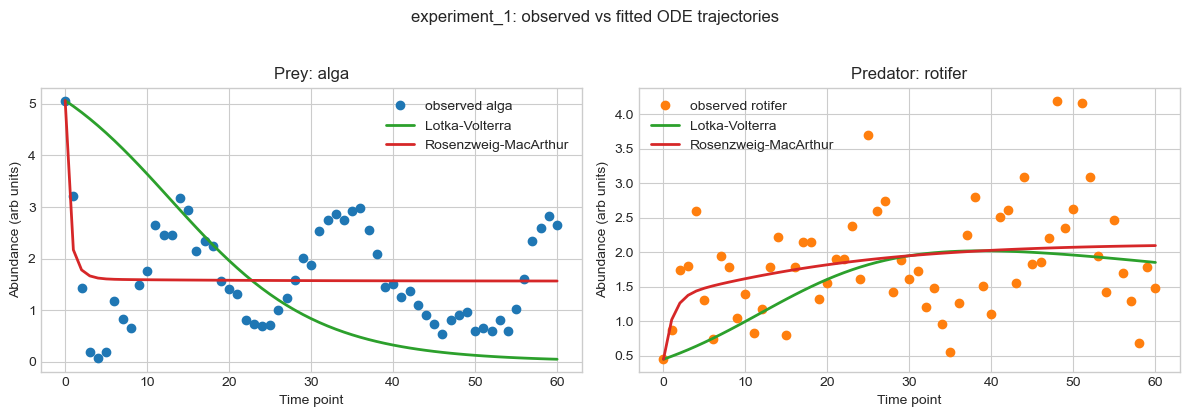

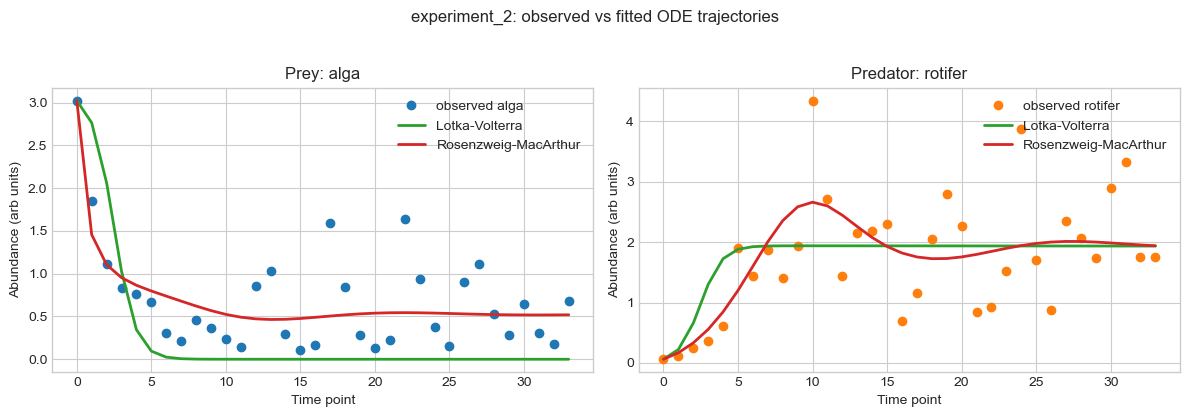

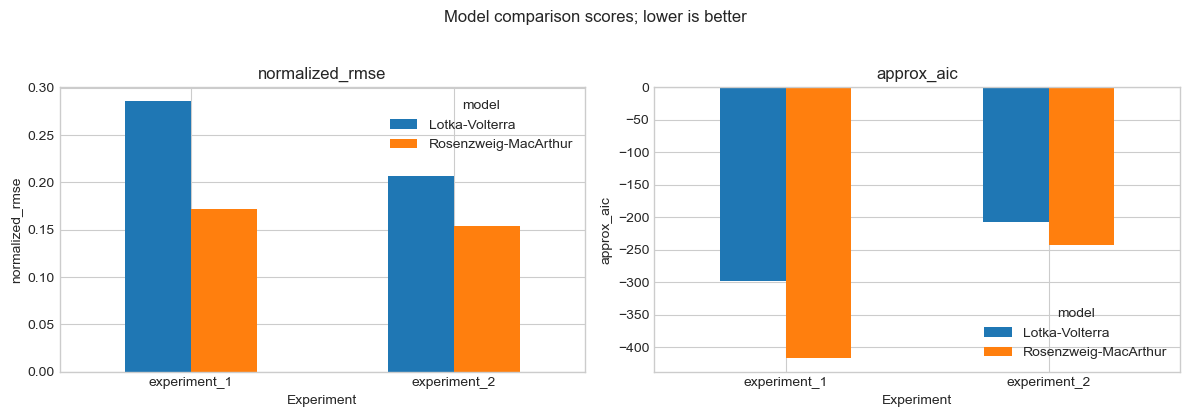

In [9]:
def plot_model_fit_comparison(experiments, predictions, output_dir):
    colors = {
        "observed_alga": "tab:blue",
        "observed_rotifer": "tab:orange",
        "Lotka-Volterra": "tab:green",
        "Rosenzweig-MacArthur": "tab:red",
    }

    for experiment_name, df in experiments.items():
        fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

        axes[0].plot(df["time"], df["alga"], "o", color=colors["observed_alga"], label="observed alga")
        axes[1].plot(df["time"], df["rotifer"], "o", color=colors["observed_rotifer"], label="observed rotifer")

        for model_name, prediction in predictions[experiment_name].items():
            axes[0].plot(prediction["time"], prediction["alga_pred"], linewidth=2, color=colors[model_name], label=model_name)
            axes[1].plot(prediction["time"], prediction["rotifer_pred"], linewidth=2, color=colors[model_name], label=model_name)

        axes[0].set_title("Prey: alga")
        axes[1].set_title("Predator: rotifer")
        for ax in axes:
            ax.set_xlabel("Time point")
            ax.set_ylabel("Abundance (arb units)")
            ax.legend()

        fig.suptitle(f"{experiment_name}: observed vs fitted ODE trajectories", y=1.03)
        fig.tight_layout()
        fig.savefig(output_dir / f"{experiment_name}_model_fit_comparison.png", dpi=300, bbox_inches="tight")
        plt.show()


def plot_model_score_comparison(fit_summary, output_dir):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, score in zip(axes, ["normalized_rmse", "approx_aic"]):
        pivot = fit_summary.pivot(index="experiment", columns="model", values=score)
        pivot.plot(kind="bar", ax=ax)
        ax.set_title(score)
        ax.set_xlabel("Experiment")
        ax.set_ylabel(score)
        ax.tick_params(axis="x", rotation=0)

    fig.suptitle("Model comparison scores; lower is better", y=1.03)
    fig.tight_layout()
    fig.savefig(output_dir / "model_score_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_model_fit_comparison(experiments, model_predictions, MODEL_OUTPUT_DIR)
plot_model_score_comparison(fit_summary, MODEL_OUTPUT_DIR)

## 9. First-pass model comparison interpretation

Use lower normalized RMSE and lower approximate AIC as the numerical comparison. Then check the fitted-trajectory plots to see whether the winning model captures biologically meaningful features such as prey suppression, predator response, and oscillation shape.

In [10]:
def print_model_comparison_interpretation(fit_summary):
    for experiment_name, group in fit_summary.groupby("experiment"):
        best_by_rmse = group.sort_values("normalized_rmse").iloc[0]
        best_by_aic = group.sort_values("approx_aic").iloc[0]
        print(f"{experiment_name}:")
        print(f"  best normalized RMSE: {best_by_rmse['model']} ({best_by_rmse['normalized_rmse']:.3f})")
        print(f"  best approximate AIC: {best_by_aic['model']} ({best_by_aic['approx_aic']:.2f})")
        print()

    print("AIC here is an approximate least-squares AIC based on normalized residuals.")
    print("Because the time axis is row index, fitted parameters should be interpreted as per-observation-step quantities, not real-time biological rates.")


print_model_comparison_interpretation(fit_summary)

experiment_1:
  best normalized RMSE: Rosenzweig-MacArthur (0.172)
  best approximate AIC: Rosenzweig-MacArthur (-416.81)

experiment_2:
  best normalized RMSE: Rosenzweig-MacArthur (0.154)
  best approximate AIC: Rosenzweig-MacArthur (-242.67)

AIC here is an approximate least-squares AIC based on normalized residuals.
Because the time axis is row index, fitted parameters should be interpreted as per-observation-step quantities, not real-time biological rates.
